In [61]:
import numpy as np
import numexpr as ne
import matplotlib.pyplot as plt
from numba import njit, prange


# **Let the Compiler Help Us Compute: Practical Compiled Code for Neuroscience**

Vectorized NumPy code is often fast. The more work we can hand over to compiled functions, the less often they have to interact with Python in order to do their work.

In this notebook, we'll look at two powerful tools for doing more computational work outside of Python's runtime:

* `numexpr` — to evaluate array expressions more efficiently
* `numba` — to compile Python functions into machine code

By the end of this notebook, we should be able to:

* Recognize when Python overhead limits performance
* Use `numexpr` to reduce interpreter overhead in array expressions
* Use Numba's `@njit` decorator to compile loop-based code
* Understand compilation overhead and when it matters
* Avoid common pitfalls that prevent compilation



---


# Section 1 — Using `numexpr` to Reduce Python Overhead

NumPy is fast because its core operations run in compiled C code. But every time we write an expression like:

```python
np.arange(10_000_000) + 1 + 2 + 3 + 4 + 5 + 6
```

Python still:

* Parses the expression
* Allocates temporary arrays
* Manages intermediate results


`numexpr` lets you create a micro-function that:

    * Minimizes temporary arrays
    * Uses multiple CPU cores automatically


### Reference

| Code                    | Description                           |
| ----------------------- | ------------------------------------- |
| `import numexpr as ne`  | Import numexpr.                       |
| `ne.evaluate(expr)`     | Evaluate an expression using numexpr. |
| `ne.NumExpr(expr)`      | Pre-compile an expression.            |
| `f(x=x)`                | Execute a compiled expression.        |
| `ne.set_num_threads(n)` | Control number of threads.            |


### Exercises

**Example**: Speed up the calculation below with `ne.evaluate`:

In [51]:
# Before (keep this cell the same, for later comparison)

x = np.random.random(10_000_000)

y = %time x * 2 + 3
y.sum()

CPU times: total: 46.9 ms
Wall time: 45.5 ms


np.float64(40001242.95833126)

In [52]:
# After (modify this code cell)

x = np.random.random(10_000_000)

y = %time ne.evaluate('x * 2 + 3')
y.sum()

CPU times: total: 0 ns
Wall time: 9.84 ms


np.float64(40001570.48751585)

**Example**: Speed up the calculation below with `ne.evaluate`:

In [57]:
# Before (keep this cell the same, for later comparison)

x = np.random.random(10_000_000)

y = %time 3 * x ** 2 + 2 * x + 1
y.sum()

CPU times: total: 109 ms
Wall time: 112 ms


np.float64(29999595.158036716)

In [58]:
# After (modify this code cell)

x = np.random.random(10_000_000)

y = %time ne.evaluate('3 * x ** 2 + 2 * x + 1')
y.sum()

CPU times: total: 0 ns
Wall time: 13.2 ms


np.float64(30000375.876974687)

**Exercise**: Speed up the timed calculation below using `ne.evaluate()`:

CPU times: total: 109 ms
Wall time: 108 ms


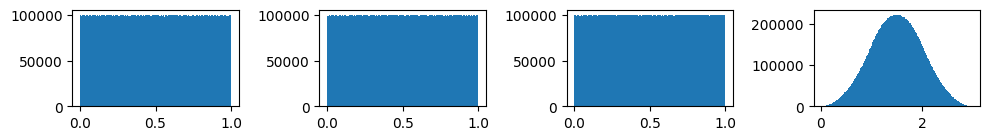

In [2]:
# Before (keep this the same, for comparison)


x = np.random.random(20_000_000)
y = np.random.random(20_000_000)
z = np.random.random(20_000_000)

total = %time x + y + z

plt.figure(figsize=(10, 1.5))
plt.subplot(1, 4, 1); plt.hist(x, bins=201);
plt.subplot(1, 4, 2); plt.hist(y, bins=201);
plt.subplot(1, 4, 3); plt.hist(z, bins=201);
plt.subplot(1, 4, 4); plt.hist(total, bins=201);
plt.tight_layout();

CPU times: total: 125 ms
Wall time: 121 ms


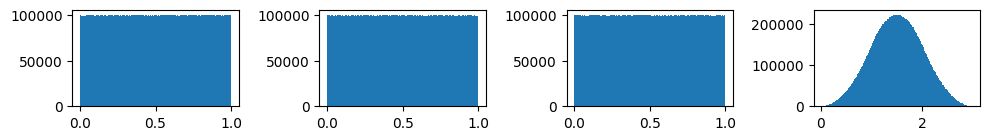

In [ ]:
# After (modify this cell)

x = np.random.random(20_000_000)
y = np.random.random(20_000_000)
z = np.random.random(20_000_000)

total = %time x + y + z

plt.figure(figsize=(10, 1.5))
plt.subplot(1, 4, 1); plt.hist(x, bins=201);
plt.subplot(1, 4, 2); plt.hist(y, bins=201);
plt.subplot(1, 4, 3); plt.hist(z, bins=201);
plt.subplot(1, 4, 4); plt.hist(total, bins=201);
plt.tight_layout();

**Exercise**: Speed up the following calculation with `np.evaluate():

In [3]:
x = np.random.random(5_000_000)

In [4]:
%%time
# Before (keep this the same, for comparison)

for _ in range(50):
    x = x * 2 * 2 * 2 * 2

CPU times: total: 3.17 s
Wall time: 3.22 s


In [5]:
%%time
# After (modify this cell)

for _ in range(50):
    x = ne.evaluate('x * 2 * 2 * 2 * 2')

CPU times: total: 7.78 s
Wall time: 763 ms


**Exercise**: Let's do it again, but this time with a smaller array.  What is different about the performance?

In [6]:
x = np.random.random(50)

In [7]:
%%time
# Before (keep this the same, for comparison)

for _ in range(50):
    x = x * 2 * 2 * 2 * 2

CPU times: total: 0 ns
Wall time: 206 μs


In [8]:
%%time
# After (modify this cell)

for _ in range(50):
    x = ne.evaluate('x * 2 + 1')

CPU times: total: 0 ns
Wall time: 856 μs


**Exercise**: Let's try the smaller case again, but this time pre-compiling the function using the pattern `f = ne.NumExpr('x + 1'); f(x)`.  How does this affect the performance?



In [10]:
%%time
# Before (keep this the same, for comparison)

for _ in range(50):
    x = x * 2 * 2 * 2 * 2

CPU times: total: 0 ns
Wall time: 230 μs


In [ ]:
%%time
# After (modify this cell)

f = ne.NumExpr('x * 2 + 1')
for _ in range(50):
    x = f(x)

CPU times: total: 0 ns
Wall time: 379 μs


**Exercise**: `numexpr` is great at helping with broadcasting, but is not a full `numpy` replacement.  Let's try it out here, and see if it helps:

In [27]:
x = np.random.random(10_000_000)

%time np.sum(np.sqrt(x))

CPU times: total: 15.6 ms
Wall time: 24.5 ms


np.float64(6666921.169906987)

In [28]:
x = np.random.random(10_000_000)

%time ne.evaluate("sum(sqrt(x))")

CPU times: total: 62.5 ms
Wall time: 49.5 ms


array(6666419.60111001)

---

## Section 2: Just-in-Time Compilation with `@njit`


In Section 1, we improved performance for vectorized array expressions, but not all problems are easy to express with pure NumPy operations.

In neuroscience, we often need:

  - Custom spike detection rules
  - Trial-by-trial logic
  - Nested loops
  - Conditional branching
  - Simulation steps

Pure Python loops are slow because:

* Every iteration runs through the Python interpreter
* Types are dynamic
* Operations are dispatched at runtime

Numba allows us to compile Python functions into machine code using Just-in-Time (JIT) compilation.

With `@njit`, we:

* Keep normal Python syntax
* Restrict ourselves to supported features
* Gain near-C speed

### Reference

| Code                     | Description                        |
| ------------------------ | ---------------------------------- |
| `from numba import njit` | Import JIT decorator.              |
| `@njit`                  | Compile function in nopython mode. |
| `@jit`                   | Compile but allow Python fallback. |
| `f.inspect_types()`      | Show inferred types.               |



### Exercises

For exach of the exercises below, we'll take an existing Python function and add `@njit`, and compare performance.

**Exercise**:  Basic Spike Counter


In [45]:
## Before (keep this the sam, for later comparison)

def count_spikes(x, threshold):
    count = 0
    for i in range(len(x)):
        if x[i] > threshold:
            count += 1
    return count


In [46]:
## Call this cell multiple times and check if the performance changes

x = np.random.random(10_000_000)
%time count_spikes(x, 0.1)

CPU times: total: 1.81 s
Wall time: 1.83 s


9000780

In [41]:
## After (moidfy this cell)

@njit
def count_spikes(x, threshold):
    count = 0
    for i in range(len(x)):
        if x[i] > threshold:
            count += 1
    return count



In [44]:
## Call this cell multiple times and check if the performance changes

x = np.random.random(10_000_000)
%time count_spikes(x, 0.1)

CPU times: total: 0 ns
Wall time: 5.21 ms


8999592

**Exercise**:  Sum of Squares

In [47]:
# Before (keep this the same, for later comparison)

def sum_of_squares(x):
    total = 0.0
    for i in range(len(x)):
        total += x[i] * x[i]
    return total


In [48]:
# Time the function here

In [ ]:
# After (add @njit to this function)

def sum_of_squares(x):
    total = 0.0
    for i in range(len(x)):
        total += x[i] * x[i]
    return total


In [ ]:
# Time the function here

**Exercise**: Conditional Logic

In [49]:
# Before (keep this the same, for later comparison)

def weighted_sum(x, threshold):
    total = 0.0
    for i in range(len(x)):
        if x[i] > threshold:
            total += x[i]
        else:
            total -= x[i]
    return total

In [50]:
# time it here

In [51]:
# After (add @njit to this one)

def weighted_sum(x, threshold):
    total = 0.0
    for i in range(len(x)):
        if x[i] > threshold:
            total += x[i]
        else:
            total -= x[i]
    return total

In [52]:
# time it here

---



# Section 3 — Requesting Parallel Execution with `parallel=True` and `prange`

Now we go one step further: we ask Numba to run loops in parallel across CPU cores.  This is helpful, for example, if we are computing spike counts independently across 200 recording channels. Each channel can be processed independently — which makes it a good candidate for parallelization.

We do this with:

  -  `@njit(parallel=True)`
  -  `prange()` instead of `range()`

However:

* Not all loops can be parallelized.
* Parallel overhead is real.
* Numba does not always parallelize even when we request it.




### Reference 

| Code                              | Description                    |
| --------------------------------- | ------------------------------ |
| `@njit(parallel=True)`            | Enable parallel compilation.   |
| `from numba import prange`        | Import parallel range.         |
| `prange(n)`                       | Parallel loop iterator.        |
| `f.parallel_diagnostics(level=4)` | Show parallel analysis report. |


### Exercises

**Exercise**: Add `(parallel=True)` and `prange()` to this function.  What performance benefit is there?

In [62]:
@njit(parallel=True)
def sum_seq(x):
    total = 0.0
    for i in prange(len(x)):
        total += x[i]
    return total


In [64]:
x = np.random.random(50_000_000)
sum_seq(x)


25001403.438635483

Run `sum_seq.parallel_diagnostics()` and give the output to an AI.  Was Numba able to paralllize this code?

In [65]:
sum_seq.parallel_diagnostics(level=4)

 
 Parallel Accelerator Optimizing:  Function sum_seq, 
C:\Users\delgr\AppData\Local\Temp\ipykernel_43432\1605433682.py (1)  


Parallel loop listing for  Function sum_seq, C:\Users\delgr\AppData\Local\Temp\ipykernel_43432\1605433682.py (1) 
--------------------------------|loop #ID
@njit(parallel=True)            | 
def sum_seq(x):                 | 
    total = 0.0                 | 
    for i in prange(len(x)):----| #0
        total += x[i]           | 
    return total                | 
--------------------------------- Fusing loops ---------------------------------
Attempting fusion of parallel loops (combines loops with similar properties)...
----------------------------- Before Optimisation ------------------------------
--------------------------------------------------------------------------------
------------------------------ After Optimisation ------------------------------
Parallel structure is already optimal.
-------------------------------------------------------------

**Exercise**: Add `(parallel=True)` and `prange()` to this function.  What performance benefit is there?

In [67]:

def dependent_loop(x):
    for i in prange(1, len(x)):
        x[i] = x[i] + x[i - 1]
    return x

In [68]:
x = np.random.random(50_000_000)
dependent_loop(x)

array([3.62559310e-01, 8.90805488e-01, 9.27104647e-01, ...,
       2.50032063e+07, 2.50032066e+07, 2.50032073e+07], shape=(50000000,))

Run `sum_seq.parallel_diagnostics()` and give the output to an AI.  Was Numba able to paralllize this code?